# NOTEBOOK NAME
Created by: Thomas Durand-Texte, 2023

# Import des packages et données
## import des packages

In [1]:
import os

import pandas as pd
import numpy as np
# import dask as dd
pd.set_option("display.max_columns", 200)
import datetime as dt
import scipy.stats as st

from statsmodels.multivariate.manova import MANOVA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda

import time

import pickle

from sklearn import model_selection, metrics, preprocessing
from sklearn import cluster

import matplotlib.pyplot as plt
import seaborn as sns
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

cm = 1./2.54
path_print = 'Figures/simulations/'

## Paramètres graphiques et fonctions utiles

In [2]:
import subprocess

white_font = True
def set_theme( white_font=True ):
    """ set_theme( white_font=True ) """
    if white_font: wht, grey, blck = '0.84' , '0.5', 'k'
    else: wht, grey, blck = 'k', '0.5', '0.84'
    rc = { 'figure.facecolor':(0.118,)*3,
            'axes.labelcolor':wht,
            'axes.edgecolor':wht,
            'axes.facecolor':(0,0,0,0),
            'text.color':'white',
            'text.usetex':False,
            'text.latex.preamble':r'\usepackage[cm]{sfmath} \usepackage{amsmath}' ,
            'font.family': 'sans-serif' ,
            'font.sans-serif': 'DejaVu Sans' ,
            'xtick.color':wht,
            'ytick.color':wht,
            "axes.grid" : True,
            "grid.color": (0.7,)*3,
            "grid.linewidth": 0.4,
            "grid.linestyle": (10,5),
            'legend.edgecolor':'0.2',
            'legend.facecolor':(0.2,0.2,0.2,0.6),
            # 'legend.framealpha':'0.6',
            'pdf.fonttype':42,
            'savefig.format':'pdf',
            'savefig.transparent':True,
            'figure.dpi':150, # for better agreemet figsize vs real size
        }

    sns.set_theme( 'notebook' , rc=rc )
    return


def make_folder( path_folder ):
    path_folder = path_folder.__str__()
    try:
        if os.path.isdir( path_folder ) : return
        os.makedirs(path_folder)
    except OSError:
        pass
    return

def concat_folders(*args, **kwargs):
    """ concat_folders(*args, **kwargs)
        concatenate folders in args (strings) """
    sPath = ''
    for arg in args:
        if arg == '..': sPath = sPath[:sPath[:-1].rfind(os.sep)+1]
        else: sPath += arg
        if sPath[-1] != os.sep: sPath += os.sep
    return sPath

class Path(object):
    """ Path( s_in='', s_lim=None)
        create a path to the string s_in (default is current path)
        and stops after s_lim """
    n_Path = 0
    def __init__(self, s_in='', s_lim=None):
        """docstring."""
        if s_in == '': s_in = os.getcwd()
        if not s_lim is None:
            if s_lim in s_in:
                s_in = s_in[ :s_in.index( s_lim ) + len(s_lim) ]
        self.sPath = concat_folders(s_in)
        self.N = Path.n_Path
        Path.n_Path += 1

    def __add__(self, other):
        """ Path + str : return str """
        if isinstance(other, str): return self.sPath + other

    def __truediv__(self, other):
        """ Path / str : return path concatenated"""
        if isinstance(other, str): return Path(concat_folders(self.sPath, other))

    def __invert__(self):
        """ ~Path : return str of the path """
        return self.sPath

    def __str__(self):
        """ __str__ return str of the path """
        return self.sPath
    # __str__ #

    def makedir( self ):
        return make_folder( self )


def gs_opt( filename ):
    """ otpimisation of a pdf file with gosthscript """
    filenameTmp = filename.replace('.pdf', '') + '_tmp.pdf'
    gs = ['gs',
            '-sDEVICE=pdfwrite',
            '-dEmbedAllFonts=true',
            '-dSubsetFonts=true',             # Create font subsets (default)
            '-dPDFSETTINGS=/prepress',        # Image resolution
            '-dDetectDuplicateImages=true',   # Embeds images used multiple times only once
            '-dCompressFonts=true',           # Compress fonts in the output (default)
            '-dNOPAUSE',                      # No pause after each image
            '-dQUIET',                        # Suppress output
            '-dBATCH',                        # Automatically exit
            '-sOutputFile='+filenameTmp,      # Save to temporary output
            filename]                         # Input file

    subprocess.run(gs)                                      # Create temporary file
    subprocess.run( 'rm -f ' + filename, shell=True)            # Delete input file
    subprocess.run( 'mv -f ' + filenameTmp + " " + filename, shell=True) # Rename temporary to input file

def savefig( fig, savename, **kwargs ):
    """ savefig( fig, savename, **kwargs )
        Saves a figure with kwargs (fig.savefig( savename, **kwargs) ).
        A check is done first to determine if a folder has to be created according to savename.
        Finally, if the file is saved as .pdf, gosthscript optimisation is performed. """
    if os.sep in savename: make_folder( savename[:savename.rindex(os.sep)] )
    fig.savefig( savename, **kwargs )
    savename += '.pdf'
    if os.path.isfile( savename ): gs_opt( savename )


def image_size_from_width_and_shape( width: float, shape: tuple, ymargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return width, width*shape[0]/shape[1]+ymargin

def image_size_from_height_and_shape( height: float, shape: tuple, xmargin=0. ):
    """ return tuple (width, height) corresponding to image shape """
    return height*shape[1]/shape[0]+xmargin, height


set_theme()
del set_theme

In [18]:
def df2ltx( data, keys_replace_columns={'_':' '}, col_format='c',keys_replace_indexes={'_':' '} ):
    # print('data', data.shape)
    n_lines, n_keys = data.shape
    strng = '\\begin{tabular}{' + '{:}'.format( col_format*(n_keys+1) ) + '}\n\t'
    strng += '\\rowcolor{dfFirstRow}\n\t'
    for col in data.columns:
        for key,val in keys_replace_columns.items():
            col = col.replace(key,val)
        strng += ' & ' + col
    i = 1
    for index, row in zip( data.index, data.values ):
        index = index.__str__()
        for key, val in keys_replace_indexes.items():
            index = index.replace(key,val)
        i = (i+1)%2
        strng += ' \\tabularnewline\n\t\\rowcolor{' + ['dfEvenRow', 'dfOddRow'][i] + '}\n\t' + index.__str__()
        for cell in row:
            cell = cell.__str__()
            if cell == 'nan': cell = 'NaN'
            strng += ' & ' + cell

    strng += '\n\\end{tabular}'
    return strng

## Chargement des données

Affichage de l'arborescence

In [3]:
def print_listdir( path=None, level=0, exclude=[] ) :
    suffix = ''
    if level > 0:
        suffix = ' |-'* level
    vals = os.listdir( path )
    vals.sort()
    if path is None:
        path = ''
    for val in vals:
        if val in exclude: continue
        print( suffix, val)
        if os.path.isdir( path + val):
            print_listdir( path + val + '/', level+1 )

print_listdir( exclude=['.venv', '.venv2', 'Figures', 'ressources', 'devel'] )

 data
 |- cleaned
 |- |- iteration_tsne_RFM.pickle
 |- |- iteration_tsne_RFM_delay.pickle
 |- |- iteration_tsne_RFM_review_score.pickle
 |- |- iteration_tsne_RFM_type_payment.pickle
 |- data_diagram.png
 |- data_diagram_resized.png
 |- source
 |- |- olist_customers_dataset.csv
 |- |- olist_customers_dataset.csv.zip
 |- |- olist_geolocation_dataset.csv
 |- |- olist_geolocation_dataset.csv.zip
 |- |- olist_order_items_dataset.csv
 |- |- olist_order_items_dataset.csv.zip
 |- |- olist_order_payments_dataset.csv
 |- |- olist_order_payments_dataset.csv.zip
 |- |- olist_order_reviews_dataset.csv
 |- |- olist_order_reviews_dataset.csv.zip
 |- |- olist_orders_dataset.csv
 |- |- olist_orders_dataset.csv.zip
 |- |- olist_products_dataset.csv
 |- |- olist_products_dataset.csv.zip
 |- |- olist_sellers_dataset.csv
 |- |- product_category_name_translation.csv
 exploration.ipynb
 install_packages_venv.sh
 install_packages_venv2.sh
 notebook.ipynb
 notebook_essais.ipynb
 notebook_simulation.ipynb


Chargement des données

In [4]:
path = 'data/source/'

filenames = ['customers', 'geolocation', 'orders', 'order_items', 'order_payments', 'order_reviews', 'products', 'sellers']
dfs = { filename: pd.read_csv( path + f'olist_{filename}_dataset' + '.csv' ) for filename in filenames }
filename = 'product_category_name_translation'
dfs[filename] = pd.read_csv( path + filename + '.csv')

path_save = 'data/cleaned/'

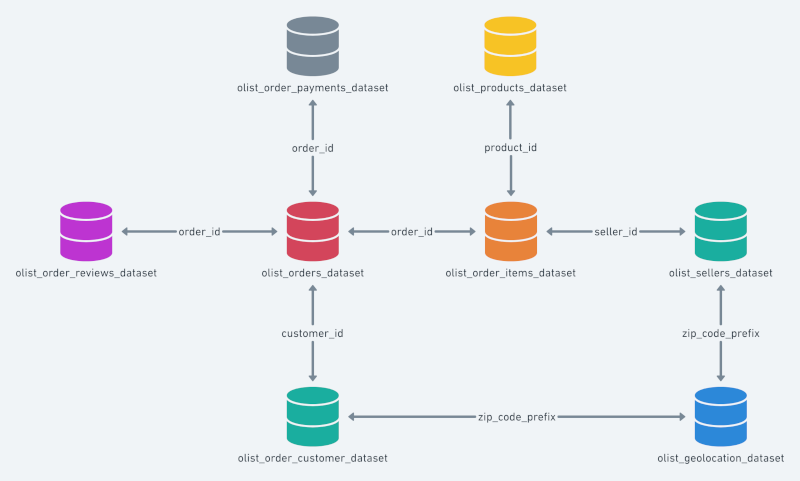

In [5]:
df_merged = dfs['orders'].merge(dfs['customers'], how='left', on='customer_id')
df_merged = df_merged.merge( dfs['order_payments'], how='left', on='order_id' )
df_merged = df_merged.merge( dfs['order_reviews'], how='left', on='order_id' )

df_merged.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
92053,bdef95213c6176d9f65a227aba558463,f8ea9a3f142e872b1e796bd1e809dd73,delivered,2018-01-17 11:12:23,2018-01-17 18:29:53,2018-01-23 21:48:50,2018-01-29 16:48:37,2018-02-16 00:00:00,25463d3b7b5fcd0499f84d2602216e72,1311,sao paulo,SP,1.0,boleto,1.0,315.33,626421920a5a61cafda2e3e9de016c2c,5.0,NaN,NaN,2018-01-30 00:00:00,2018-01-30 21:11:49
83057,b8a0ea35d4a5efa22c003976eb138ebc,bb0b336b64ce8d27877043e5f9477e67,delivered,2018-08-06 14:10:47,2018-08-07 04:15:31,2018-08-07 18:13:00,2018-08-08 13:59:33,2018-08-09 00:00:00,63a5d1be2682f35c9a9ae974dc9a293f,2420,sao paulo,SP,1.0,boleto,1.0,85.81,53b6d6e52e0ac20ccf639f75f75961be,5.0,NaN,NaN,2018-08-09 00:00:00,2018-08-09 17:14:48
58193,c37d41945512f0cfbcdd0f085bbd04d8,f4e2bcb516a63a0b3cf24b4c94ee2209,delivered,2018-07-13 14:58:58,2018-07-17 04:32:27,2018-07-18 15:00:00,2018-07-24 20:16:55,2018-08-02 00:00:00,ee8378c69767aecc3ce2743d62173ff5,74810,goiania,GO,1.0,boleto,1.0,222.08,5d5fc3469a301224faba3904899d3964,5.0,otimo,NaN,2018-07-25 00:00:00,2018-07-26 14:38:37
97423,2d03cd6c5d4ef95593a9f4ecff1b48cb,00bf225ae2b2d6a141e31acf971c4a03,delivered,2018-03-14 22:12:44,2018-03-14 22:29:51,2018-03-19 18:05:50,2018-03-20 19:18:30,2018-03-26 00:00:00,c60c5563690f2a27a76f4d8ba53c2a85,1440,sao paulo,SP,1.0,voucher,1.0,42.38,2e8343b426eebcfad8c51c830986a087,5.0,NaN,NaN,2018-03-21 00:00:00,2018-03-22 16:20:30
6789,3762c0ef92b5bc397671e6d7e6d5672f,39bb2424304a318278cf4516500c657c,delivered,2017-08-15 21:32:14,2017-08-15 23:30:19,2017-08-17 18:47:31,2017-08-22 22:42:13,2017-09-12 00:00:00,cdc6cd6f0a8b8f844db9a61e779055b3,6270,osasco,SP,1.0,credit_card,3.0,73.34,1c9b965575ce36519e5065662c06406e,5.0,NaN,NaN,2017-08-23 00:00:00,2017-08-25 10:18:26


In [6]:
timestamp_cols = ['order_purchase_timestamp', 'order_approved_at',
                    'order_delivered_carrier_date', 'order_delivered_customer_date',
                    'order_estimated_delivery_date']
for col in timestamp_cols:
    df_merged[col] = pd.to_datetime(df_merged[col])

In [8]:
print( 'customer_id :', df_merged['customer_id'].value_counts().shape ) 
print( 'customer_unique_id :', df_merged['customer_unique_id'].value_counts().shape )


groups = df_merged[['customer_unique_id',
                      'payment_value']].copy()
groups['number_of_days_since_last_order'] = (df_merged['order_purchase_timestamp'].max() - df_merged['order_purchase_timestamp']).dt.days

groups = groups.groupby( by='customer_unique_id' )

df_model = groups.agg( {'number_of_days_since_last_order':'max',
                        'customer_unique_id':'count',
                        'payment_value':'sum'} )
df_model.rename( columns={'number_of_days_since_last_order':'Recence',
                    'customer_unique_id':'Frequence',
                    'payment_value':'Montant'}, inplace=True )

display( df_model.iloc[18:27,:] )

customer_id : (99441,)
customer_unique_id : (96096,)


,Recence,Frequence,Montant
customer_unique_id,,,
000de6019bb59f34c099a907c151d855,425,1,257.44
000e309254ab1fc5ba99dd469d36bdb4,114,2,78.42
000ec5bff359e1c0ad76a81a45cb598f,57,1,27.75
000ed48ceeb6f4bf8ad021a10a3c7b43,150,1,20.75
000fbf0473c10fc1ab6f8d2d286ce20c,83,1,362.38
0010a452c6d13139e50b57f19f52e04e,463,1,325.93
0010fb34b966d44409382af9e8fd5b77,226,1,61.80
001147e649a7b1afd577e873841632dd,412,1,212.16
00115fc7123b5310cf6d3a3aa932699e,633,1,76.11


# Fonctions utiles

In [19]:
def describe_clusters_centers( model, scaler, features, labels, title, sort_order=None ):
    path_print_tmp = path_print + title.replace(' ', '_') + '/'
    df_clusters = pd.DataFrame( scaler.inverse_transform(model.cluster_centers_), columns=features )

    # labels = model.predict( X_scaled )
    unique, counts = np.unique( labels, return_counts=True )

    df_clusters.loc[ unique, 'count' ] = counts
    df_clusters['count'] = df_clusters['count'].astype(int)
    df_clusters['count (%)'] = df_clusters['count'] * (100 / df_clusters['count'].sum() )
    # df_clusters.info()
    if sort_order is None:
        sort_order = df_clusters.index
        # display( df_clusters.round(2) )

    tmp = df_clusters.loc[sort_order,:].round(2)

    df_ltx = tmp.copy() # to be saved below

    tmp = tmp.style.set_caption( title )
    display( tmp )

    tmp = df_clusters.drop( columns='count (%)')
    # normalisation for radar
    max_values = tmp.max(0)
    # max_values['count'] = tmp['count'].sum()
    # print( max_values )
    tmp.loc[:,:] = tmp.values / max_values.values.reshape(1,-1)
    tmp['Recence'] = 1 - tmp['Recence']
    tmp['Recence'] /= tmp['Recence'].max()
    tmp *= 5
    # display(tmp)
    # tmp = tmp.sort_values( by=tmp.columns.tolist(), ascending=False )
    # display(tmp)

    fig, ax = plt.subplots( figsize=(5,5), subplot_kw={'projection':'polar'} )
    fig.suptitle( title )
    ax.grid( True )
    categs = tmp.columns
    theta = np.linspace( 0, 2*np.pi, len(categs), endpoint=False )
    ax.set_xticks( theta )
    ax.set_xticklabels( categs )
    ax.set_yticklabels([])
    # import plotly.graph_objects as go
    # fig = go.Figure()
    # display(tmp)
    markersizes = np.linspace( 10, 5, len(tmp.index))
    j = 0
    for i in tmp.index:
        # fig.add_trace(go.Scatterpolar(
        #     r=tmp.iloc[i,:].values,
        #     theta=tmp.columns,
        #     name=f'group {i}'
        #     ))
        # print('i', i, 'values', tmp.loc[i,:].values )
        ax.plot( theta, tmp.loc[i,:].values, 'o-', label=f'group {i}', markersize=markersizes[j])
        j += 1
    ax.legend()
    fig.tight_layout( )

    savefig( fig, path_print_tmp + 'polar_centers' ) # create folder and save plot
    with open( path_print_tmp + 'ltx_DataFrame_centers', 'w') as file:
        file.write( df2ltx(df_ltx) )

    # dfs_polar = []
    # for i in tmp.index:
    #     df_polar = pd.DataFrame()
    #     df_polar['theta'] = tmp.columns
    #     df_polar['r'] = tmp.iloc[i,:].values
    #     df_polar['group'] = i
    #     df_polar = pd.concat( (df_polar, df_polar.loc[:1,:]) ) # avoid line_close=True which provocs a warning
    #     dfs_polar.append( df_polar )

    # df_polar = pd.concat( dfs_polar, axis=0 )
    # # display( df_polar )
    # fig = px.line_polar( df_polar, r='r', theta='theta', color='group', line_close=False)

    # fig.show()



def analyse_results( X, labels, features, path_print=None ) :

    inds = { label: labels==label for label in np.unique(labels) }
    # for label in np.unique( labels ):
    #     Xtmp = X[inds[label]]
    #     # Analyse univariée pour chaque variable
    #     fig, axs = plt.subplots( figsize=(5,5), nrows=X.shape[1] )
    #     for i, feat in enumerate(features):
    #         axs[i].hist( Xtmp[:,i], bins=30 )
    #         axs[i].set_xlabel( feat )
    #     fig.suptitle( f'cluser {label}: {Xtmp.shape[0]} members ({Xtmp.shape[0]/X.shape[0]:.2%})')
    #     fig.tight_layout()

    print('\n\n|' + 40*'-' + '|')
    print( f"{ f'{len(inds)} labels' :^42}" + '\n')


    fig, ax = plt.subplots( figsize=(10*cm,10*cm))
    pd.Series( {label: values.sum() for label,values in inds.items()} ).sort_values(ascending=True).plot( kind='pie' , ax=ax, autopct='%.1f%%' )
    ax.set_title( 'groups count (%)')
    fig.tight_layout()
    if not path_print is None:
        savefig( fig, path_print + 'pie' )

    # dataframe with category
    df = pd.DataFrame( X, columns=features )
    df['cluster'] = labels
    df['cluster'] = df['cluster'].astype('category')


    varkeys = df.columns.tolist()[:-1]
    # MANOVA
    fit = MANOVA.from_formula( ' + '.join( varkeys ) + ' ~ cluster', data=df)
    print(fit.mv_test())

    X2 = df[varkeys]
    y = df['cluster']
    post_hoc = lda().fit(X=X2, y=y)
    print('\nVARKEYS:', varkeys, '\nX2:', X2.shape)
    print('transform:', post_hoc.transform(X2).shape )

    # get Prior probabilities of groups:
    # post_hoc.priors_

    # get group means
    # post_hoc.means_

    # get Coefficients of linear discriminants
    # post_hoc.scalings_

    # get Proportion of trace (variance explained by each of the selected components)
    # post_hoc.explained_variance_ratio_

    X_new = post_hoc.transform(X2)
    X_new = pd.DataFrame( X_new, columns=[ f"lda{i+1}" for i in range( X_new.shape[1] ) ])
    X_new["cluster"] = df["cluster"]

    g = sns.pairplot(X_new, vars=['lda1', 'lda2', 'lda3'], hue='cluster',corner=True, plot_kws={'s':3})
    g.fig.suptitle( 'Linear Discriminant Analysis')
    g.fig.tight_layout()
    if not path_print is None:
        # savefig( g.fig, path_print + 'LDA' ) # too heavy for pdf
        g.fig.savefig( path_print + 'LDA.png' )

    # df.hist( column='Frequence', by='cluster', bins=30, legend=True)


    # * RECENCE
    i = 0
    fig, ax = plt.subplots( figsize=(7,3) )
    # ax.hist( [X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True )
    df.groupby('cluster')[features[i]].plot( kind='density' )
    ax.legend()
    ax.set_xlabel( features[i] )

    fig.tight_layout()
    if not path_print is None:
        savefig( fig, path_print + 'Recence' )


    # * FREQUENCE
    i = 1
    # labels_freq = ['']
    # data_histo_Frequence = [np.array([])]
    # for label in inds.keys():
    #     tmp = X[inds[label], i]
    #     if (tmp < 2.5).sum() == tmp.size:
    #         data_histo_Frequence[0] = np.concatenate( (data_histo_Frequence[0], tmp) )
    #         labels_freq[0] += f'-{label}'
    #         continue
    #     data_histo_Frequence.append( tmp )
    #     labels_freq.append( f'{label}' )
    # labels_freq[0] = labels_freq[0][1:] # remove first -

    fig, ax = plt.subplots( figsize=(7,3) )
    # ax.hist( data_histo_Frequence, label=labels_freq, bins=np.arange( 0.5, 0.5+df['Frequence'].max() ) )

    # hists = []
    bins = np.arange( 0.5, 0.5+df['Frequence'].max() )
    for label in inds.keys():
        hist, _ = np.histogram( X[inds[label], i], bins )
        # hists.append( hist )
        if label == 0 :
            markersize=10
        else:
            markersize=7
        ax.plot( bins[1:]+0.5, hist, 'o-', label=label, markersize=markersize )
    # df.groupby('cluster')[features[i]].plot( kind='hist', bins=np.arange( 0.5, 0.5+df['Frequence'].max() ) )
    ax.set_yscale('log')
    ax.set_xlabel( features[i] )
    lgd = ax.legend()
    for text in lgd.get_texts():
        ii = int( text.get_text() )
        ratio = inds[ii].sum() / X.shape[0]
        text.set_text( f'{ii}: {ratio:.2%}' )
    # display( lgd_texts[0].get_text() )

    fig.tight_layout()
    if not path_print is None:
        savefig( fig, path_print + 'Frequence' )

    # * MONTANT
    i = 2
    fig, ax = plt.subplots( figsize=(7,3) )
    # ax.hist( [X[inds[label],0] for label in inds.keys()], label=list(inds.keys()) , density=True )
    df.groupby('cluster')[features[i]].plot( kind='density' )
    ax.legend()
    ax.set_xlabel( features[i] )
    ax.set_xlim( [1, ax.get_xlim()[1]])
    ax.set_xscale('log')

    fig.tight_layout()
    if not path_print is None:
        savefig( fig, path_print + 'Montant' )


    g = sns.pairplot(df, vars=features, hue='cluster',corner=True, plot_kws={'s':3})
    # g.axes[1,1].set_yscale( 'log' )
    # g.axes[2,1].set_xscale( 'log' )
    g.axes[2,0].set_yscale( 'log' )
    g.axes[2,2].set_xscale( 'log' )
    g.axes[2,2].set_xticks( [1, 10, 100, 1000] )
    g.axes[2,2].grid( which='both', color='w' )
    g.axes[2,2].set_xlim( [9, 1000 + 1000*int(df['Montant'].max() // 1000)] )
    g.axes[2,0].set_ylim( [9, 1000 + 1000*int(df['Montant'].max() // 1000)] )
    # g = sns.PairGrid(df, vars=features, hue='cluster',corner=True)
    # g.map_diag(plt.hist)
    # g.map_lower(sns.scatterplot, s=6)
    g.fig.suptitle('Pair Plot initial features')
    g.fig.tight_layout()
    if not path_print is None:
        # savefig( g.fig, path_print + 'pairplot' ) # too heavy for pdf
        g.fig.savefig( path_print + 'pairplot.png' )
    return

# Contrat de maintenance

In [29]:
def extract_data( df, date_init, timespan ):
    loc = ( df['order_purchase_timestamp'] >= date_init ) & ( df['order_purchase_timestamp'] < (date_init+timespan))
    tmp = df.loc[loc,:]
    out = tmp[ ['customer_unique_id',
                      'payment_value'] ].copy()
    out['number_of_days_since_last_order'] = ((date_init+timespan) - tmp['order_purchase_timestamp']).dt.days
    out = out.groupby( by='customer_unique_id' )
    out = out.agg( {'number_of_days_since_last_order':'max',
                        'customer_unique_id':'count',
                        'payment_value':'sum',
                    } )

    out.rename( columns={'number_of_days_since_last_order':'Recence',
                        'customer_unique_id':'Frequence',
                        'payment_value':'Montant'
                        }, inplace=True )

    return out


def compute_ARI_full( df, t0, timespan, timeshift, k ):
    df0 = extract_data( df, t0, timespan )
    # display( df0.head(5))
    scaler0 = preprocessing.StandardScaler( )
    M0 = cluster.KMeans( k, n_init=1, init='k-means++', random_state=5 )
    L0 = M0.fit_predict( scaler0.fit_transform( df0.values ) )

    tmp = path_print + f'k_{k}/'
    describe_clusters_centers( M0, scaler0, df0.columns, L0, f'k means initial (k={k})' )
    analyse_results( df0.values, L0, df0.columns, path_print=tmp )

    t_max = df['order_purchase_timestamp'].max()
    print( 'max order purchase:', t_max, '\n' )

    ari_values = []
    time_deltas = []
    ti = t0
    while True:
        ti += timeshift
        if (ti + timespan) > t_max:
            break
        # PRINT CURRENT TI TO FOLLOW PROGRESS
        print('ti:', ti, end='\r')
        # GET DATA
        dfi = extract_data( df, ti, timespan )

        # PREDICTION WITH INITIAL MODEL
        Li0 = M0.predict( scaler0.transform( dfi.values ) )

        # NEW MODEL
        scaler_i = preprocessing.StandardScaler( )
        Mi = cluster.KMeans( k, n_init=1, init='k-means++', random_state=5 )
        Xi_scaled = scaler_i.fit_transform( dfi.values )
        Li = Mi.fit_predict( Xi_scaled )
        # Li = Mi.predict( Xi_scaled )

        # CALCUL ARI SCORE
        score = metrics.adjusted_rand_score( Li0, Li )

        # STORE DATA
        ari_values.append( score )
        time_deltas.append( (ti-t0).days/7 )
    ari_values = np.array( ari_values )
    time_deltas = np.array( time_deltas )
    print('')



    fig, ax = plt.subplots( figsize=(7,3) )
    ax.plot( time_deltas, ari_values, '-o' )
    ax.set_xlabel( 'time shift (week)' )
    ax.set_ylabel( 'ARI score' )

    ax.set_ylim( ax.get_ylim() )

    color = 'y'
    i_lim = np.arange( ari_values.size )[( ari_values < 0.8)][0]
    ax.plot( time_deltas[i_lim], ari_values[i_lim], color + 'o' )
    ax.vlines( time_deltas[i_lim], 0.32, 0.96, color=color, linestyles='--' )
    _ = ax.annotate( f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.91], va='bottom', ha='left', color=color)


    color = 'r'
    i_lim = np.arange( ari_values.size )[( ari_values < 0.8)][1]
    ax.plot( time_deltas[i_lim], ari_values[i_lim], color + 'o' )
    ax.vlines( time_deltas[i_lim], 0.32, 0.87, color=color, linestyles='--' )

    _ = ax.annotate( f'{ari_values[i_lim]:.2f} at {int(time_deltas[i_lim])} weeks', [time_deltas[i_lim]+1.3, 0.81], va='bottom', ha='left', color=color)

    fig.tight_layout()
    savefig( fig, tmp + 'ARI')

t0 = pd.Timestamp( '2017-01-01 00:00:00' )
timespan = pd.Timedelta( '365d')
timeshift = pd.Timedelta( '7d')

print('t0:', t0)
print('t1:', t0 + timespan)


t0: 2017-01-01 00:00:00
t1: 2018-01-01 00:00:00


## k = 5

,Recence,Frequence,Montant,count,count (%)
0,237.560000,1.060000,134.350000,17164,39.270000
1,68.680000,1.040000,134.480000,24588,56.250000
2,158.060000,4.360000,260.680000,607,1.390000
3,200.670000,1.170000,7622.930000,6,0.010000
4,143.200000,1.110000,1097.910000,1348,3.080000


/bin/sh: -c: line 1: syntax error near unexpected token `('
/bin/sh: -c: line 1: `rm -f Figures/simulations/k_means_initial_(k=5)/polar_centers.pdf'
/bin/sh: -c: line 1: syntax error near unexpected token `('
/bin/sh: -c: line 1: `mv -f Figures/simulations/k_means_initial_(k=5)/polar_centers_tmp.pdf Figures/simulations/k_means_initial_(k=5)/polar_centers.pdf'




|----------------------------------------|
                 5 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda  0.0838 3.0000 43706.0000 159247.4201 0.0000
         Pillai's trace  0.9162 3.0000 43706.0000 159247.4201 0.0000
 Hotelling-Lawley trace 10.9308 3.0000 43706.0000 159247.4201 0.0000
    Roy's greatest root 10.9308 3.0000 43706.0000 159247.4201 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
        cluster         Value   Num DF    Den DF    F Value   Pr > F
------------------------------------

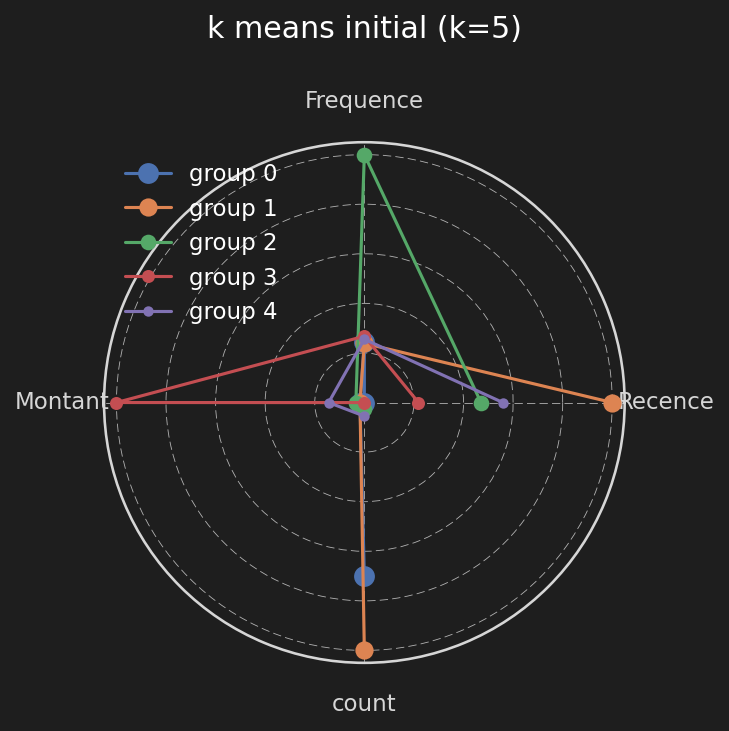

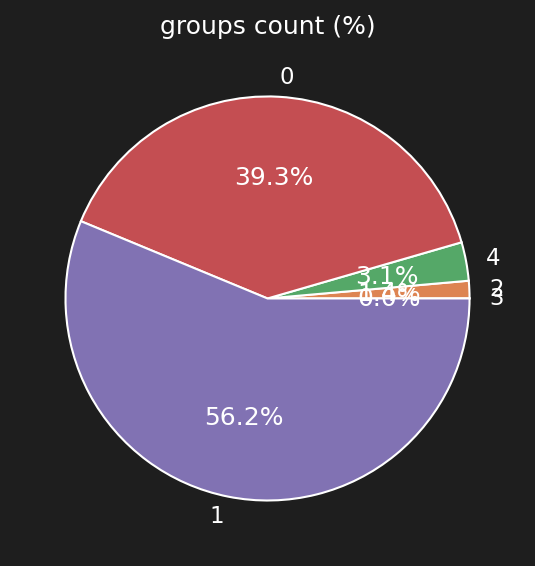

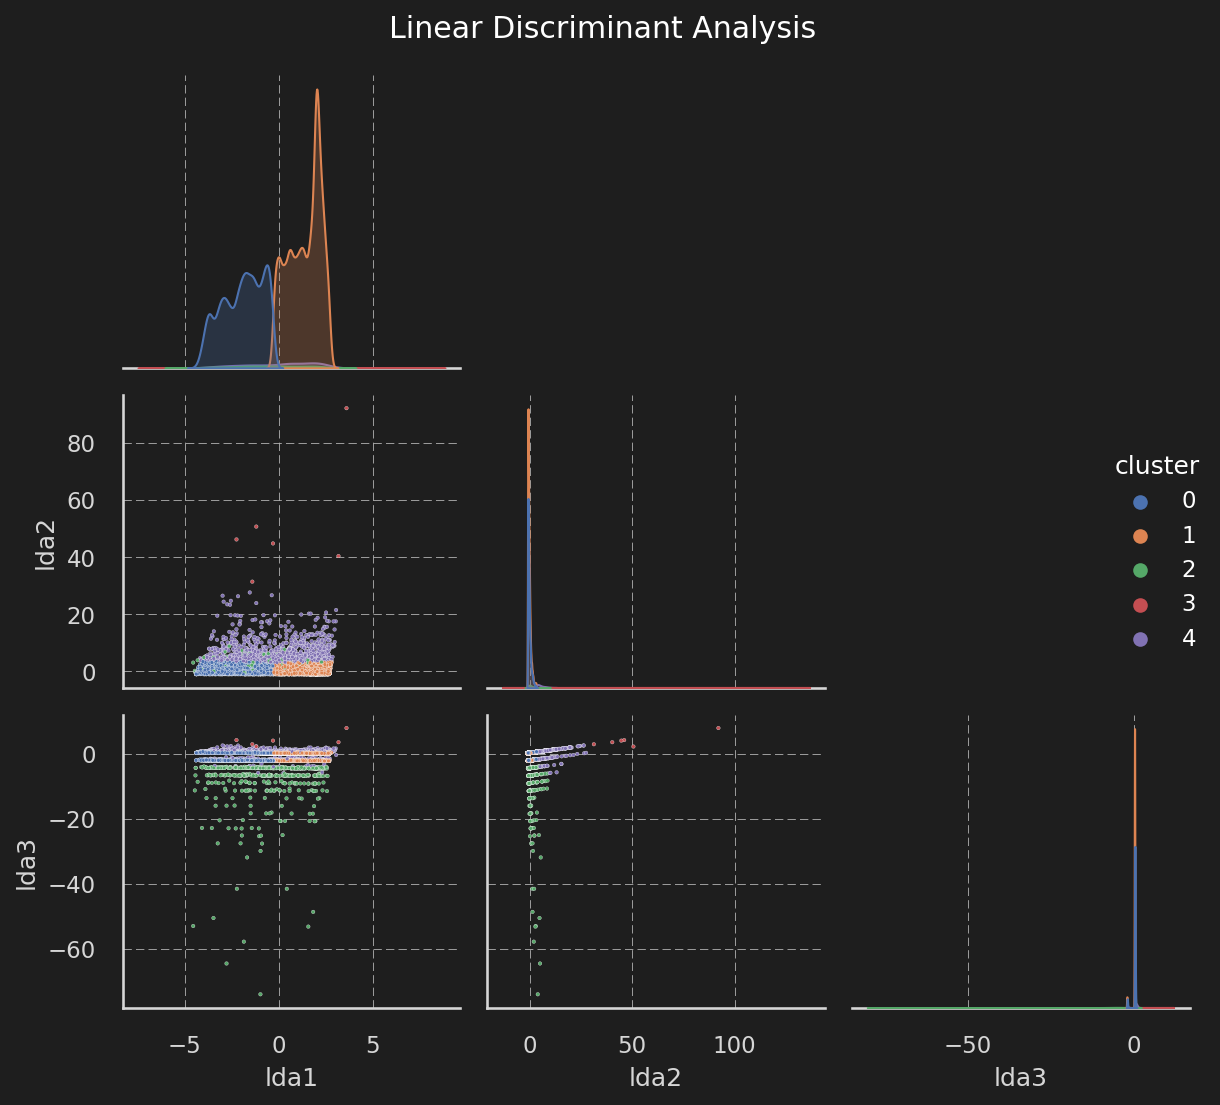

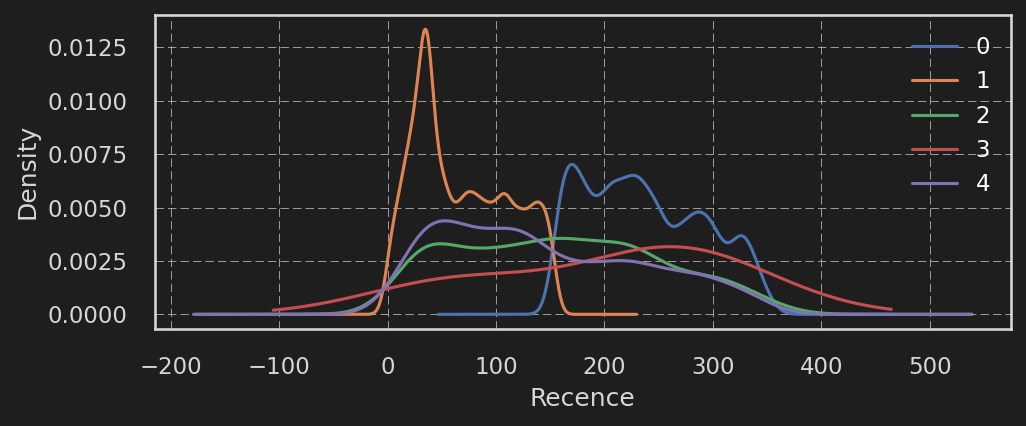

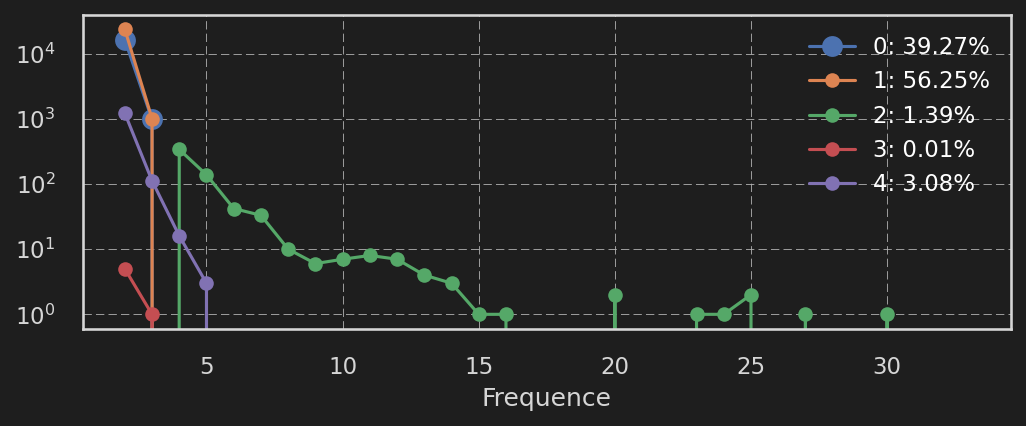

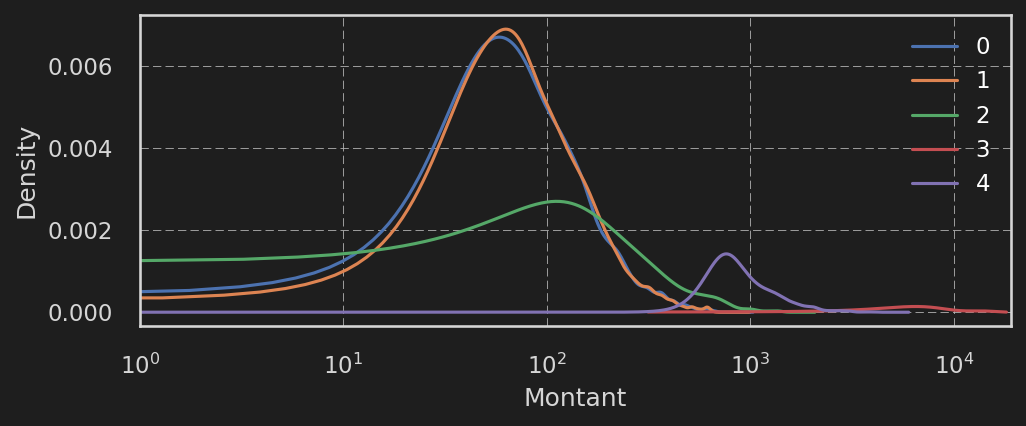

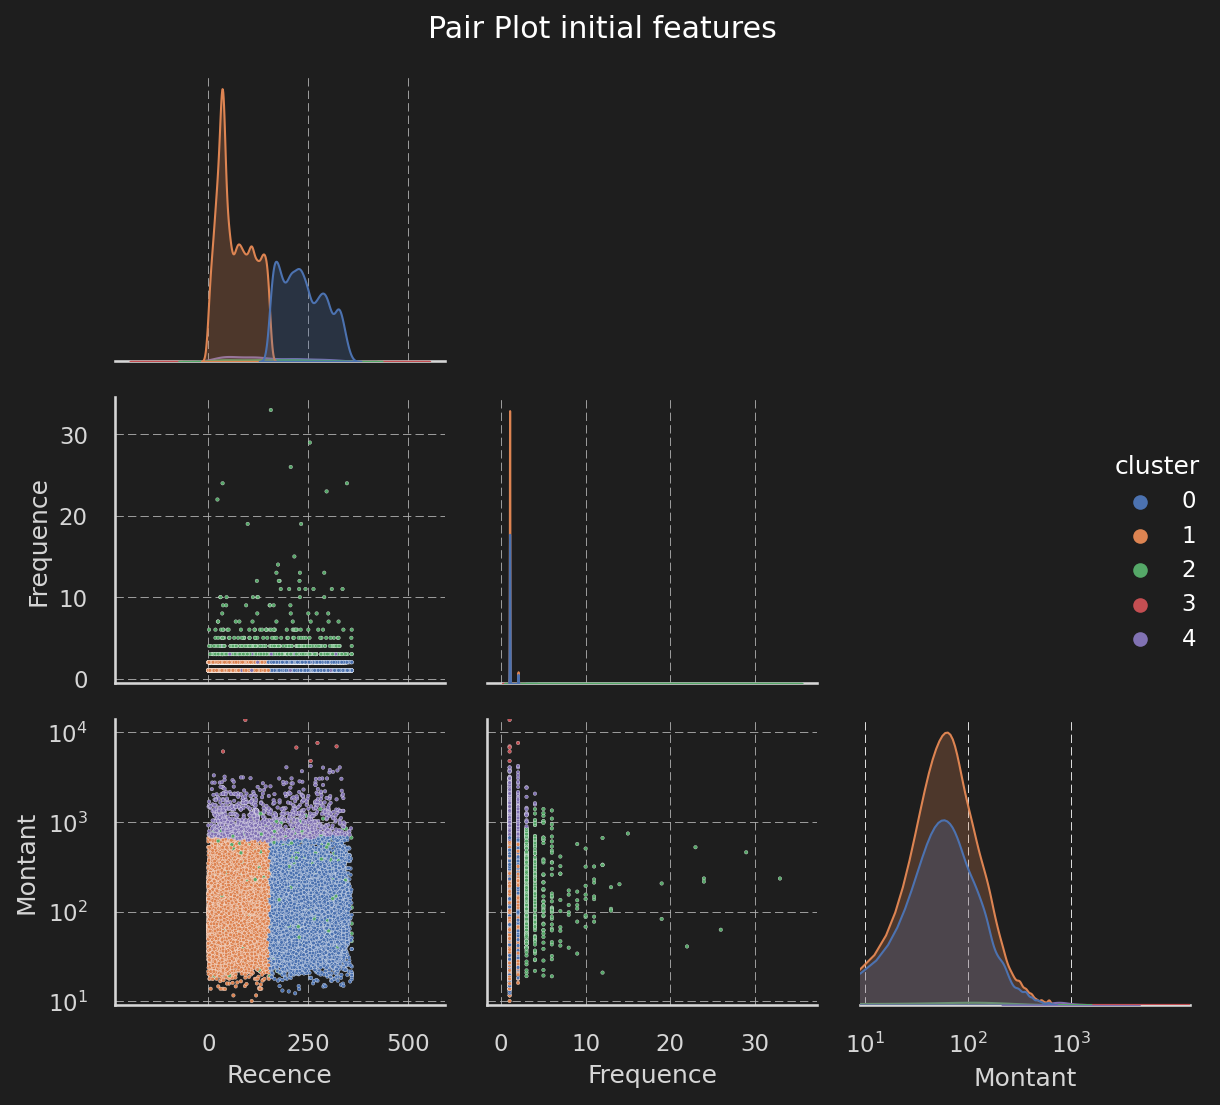

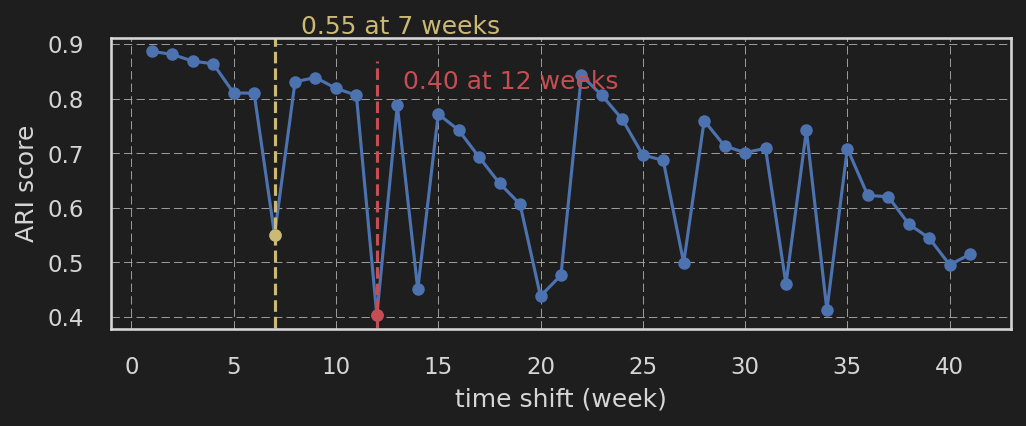

In [30]:
k = 5
compute_ARI_full( df_merged, t0, timespan, timeshift, k )

## k = 4

,Recence,Frequence,Montant,count,count (%)
0,237.580000,1.060000,137.560000,17267,39.500000
1,68.740000,1.040000,138.310000,24765,56.650000
2,157.860000,4.360000,262.690000,609,1.390000
3,145.230000,1.130000,1245.940000,1072,2.450000


/bin/sh: -c: line 1: syntax error near unexpected token `('
/bin/sh: -c: line 1: `rm -f Figures/simulations/k_means_initial_(k=4)/polar_centers.pdf'
/bin/sh: -c: line 1: syntax error near unexpected token `('
/bin/sh: -c: line 1: `mv -f Figures/simulations/k_means_initial_(k=4)/polar_centers_tmp.pdf Figures/simulations/k_means_initial_(k=4)/polar_centers.pdf'




|----------------------------------------|
                 4 labels                 

                     Multivariate linear model
                                                                    
--------------------------------------------------------------------
       Intercept         Value  Num DF   Den DF     F Value   Pr > F
--------------------------------------------------------------------
          Wilks' lambda  0.0828 3.0000 43707.0000 161483.0931 0.0000
         Pillai's trace  0.9172 3.0000 43707.0000 161483.0931 0.0000
 Hotelling-Lawley trace 11.0840 3.0000 43707.0000 161483.0931 0.0000
    Roy's greatest root 11.0840 3.0000 43707.0000 161483.0931 0.0000
--------------------------------------------------------------------
                                                                    
--------------------------------------------------------------------
         cluster         Value  Num DF    Den DF    F Value   Pr > F
------------------------------------

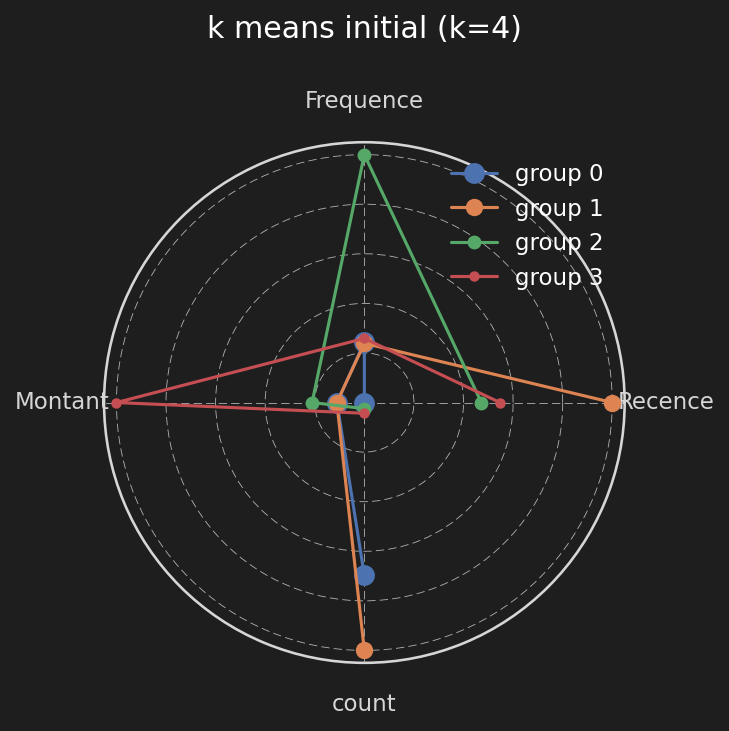

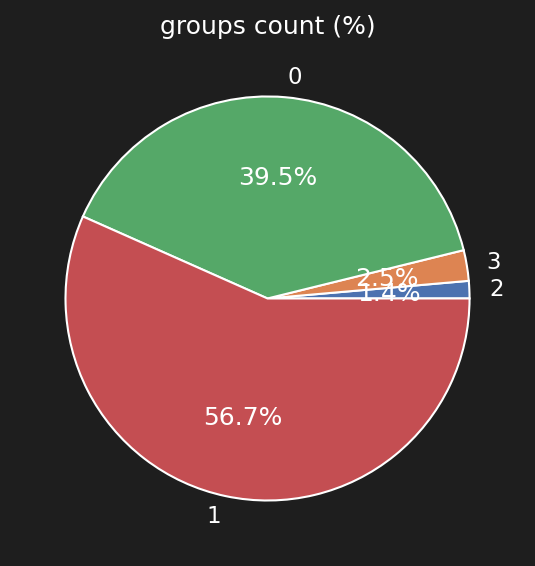

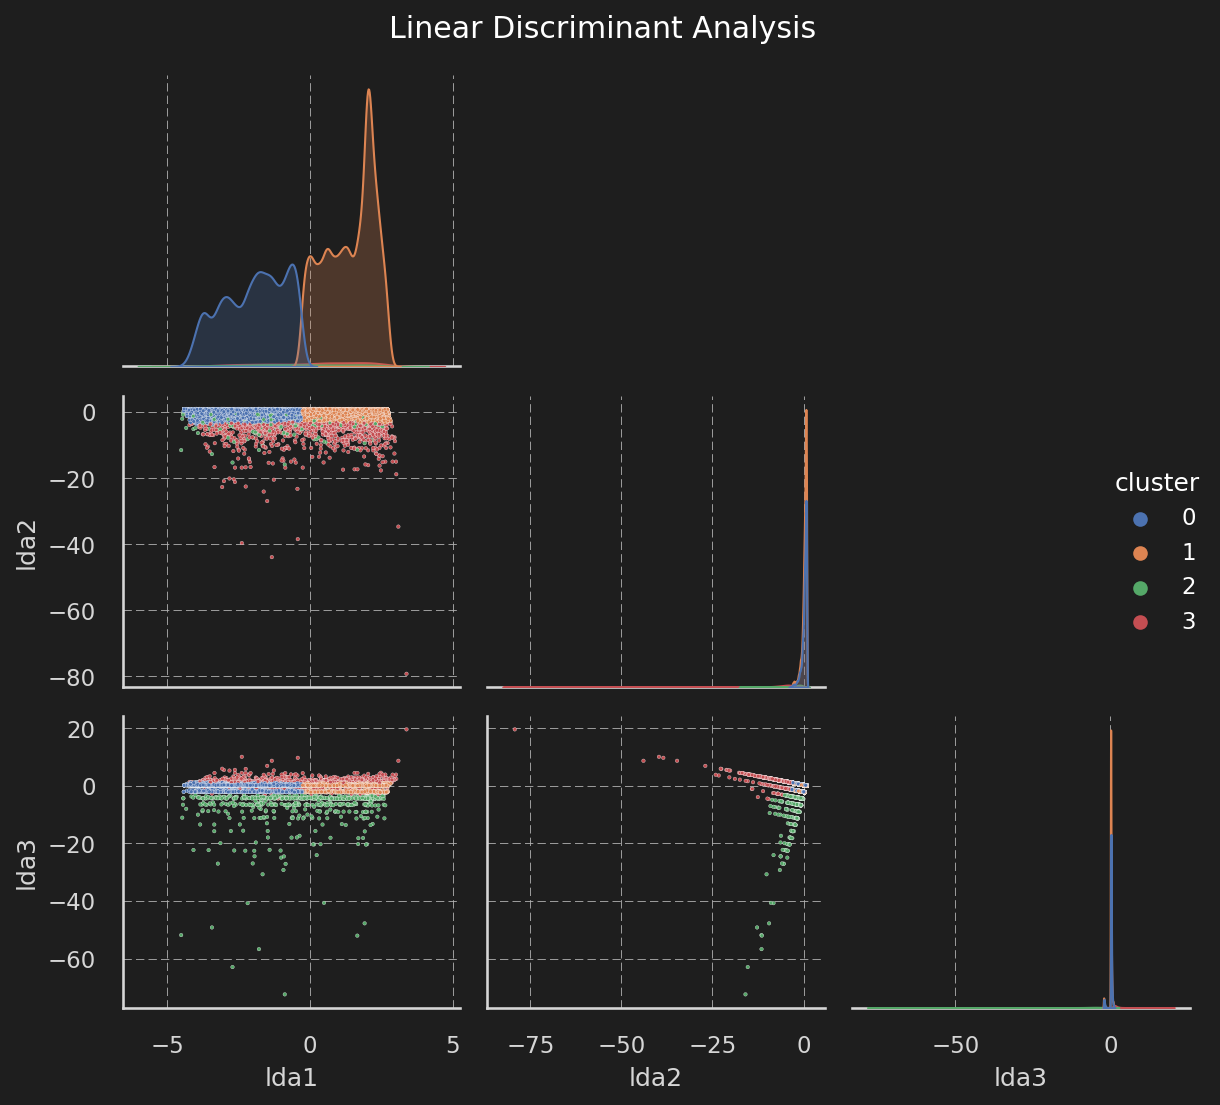

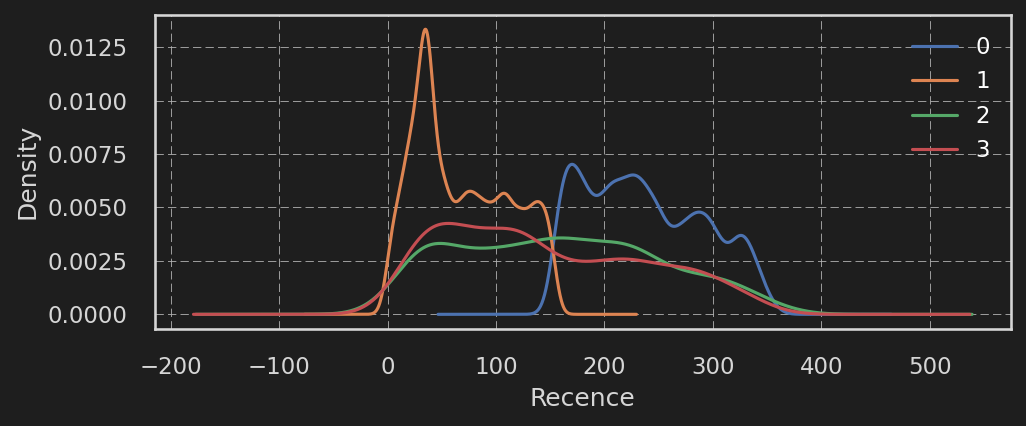

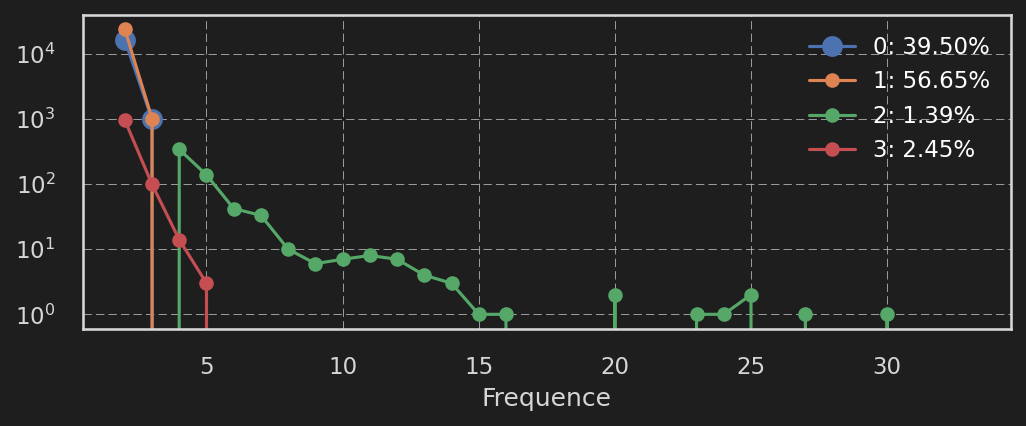

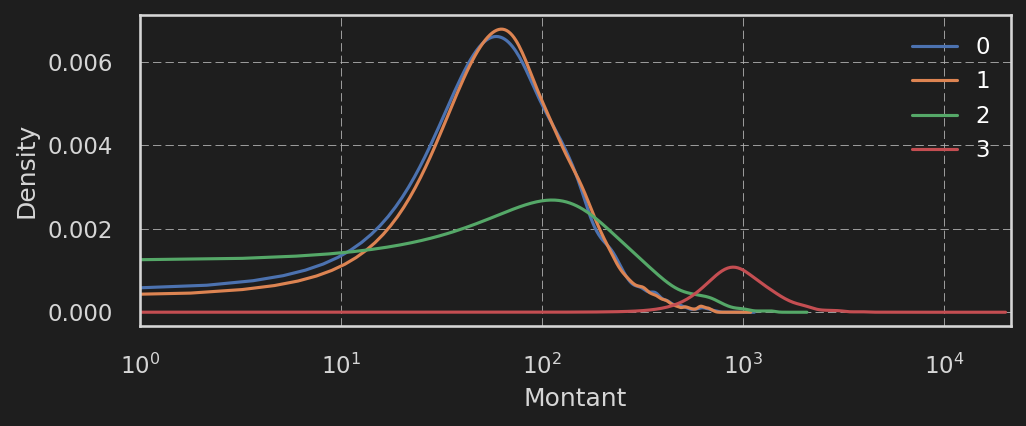

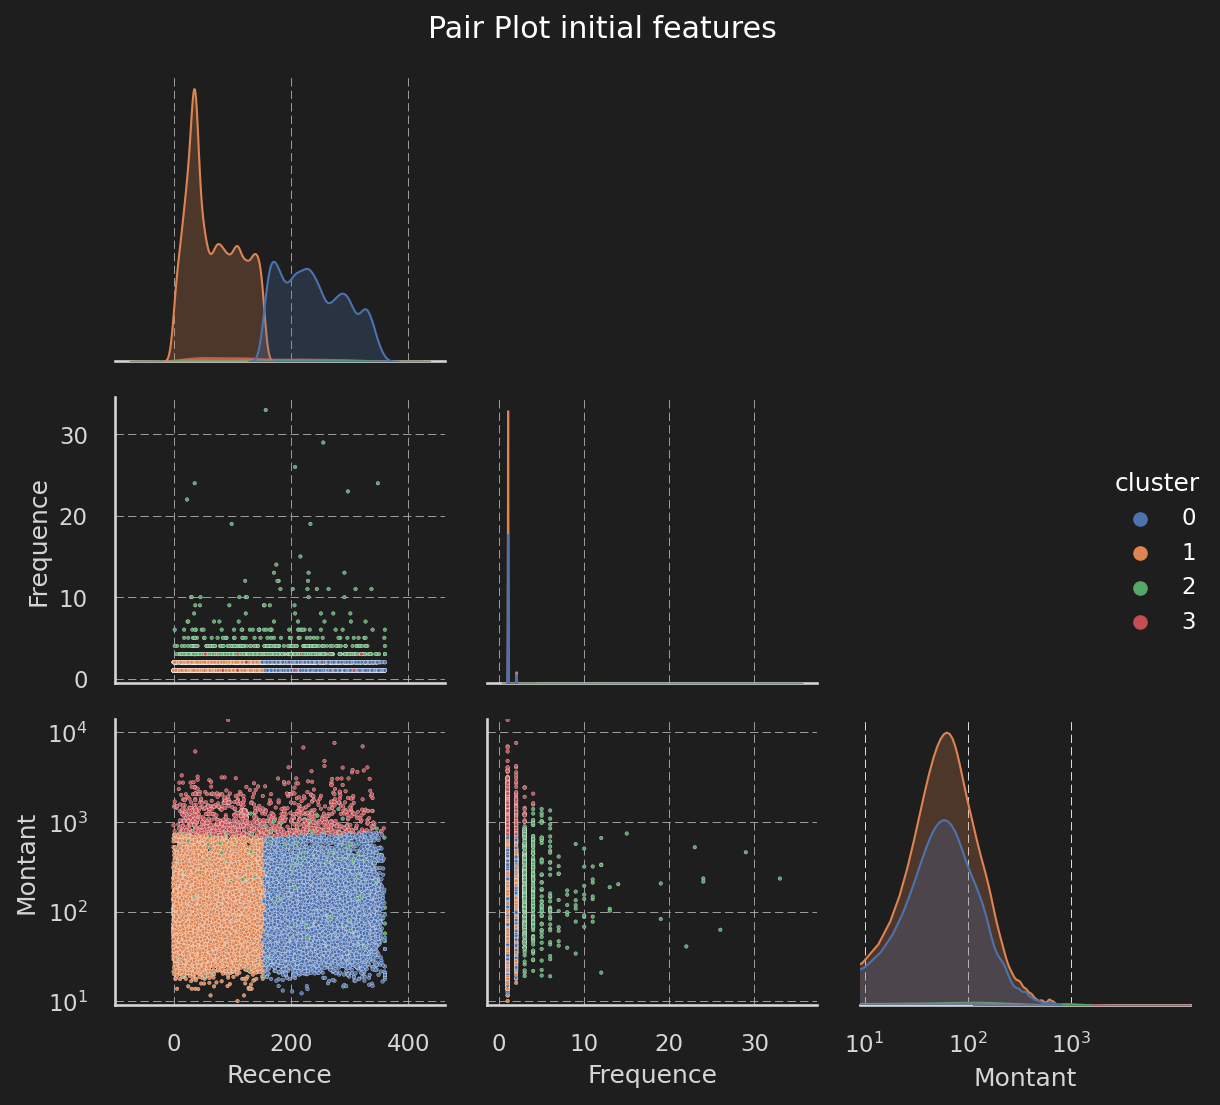

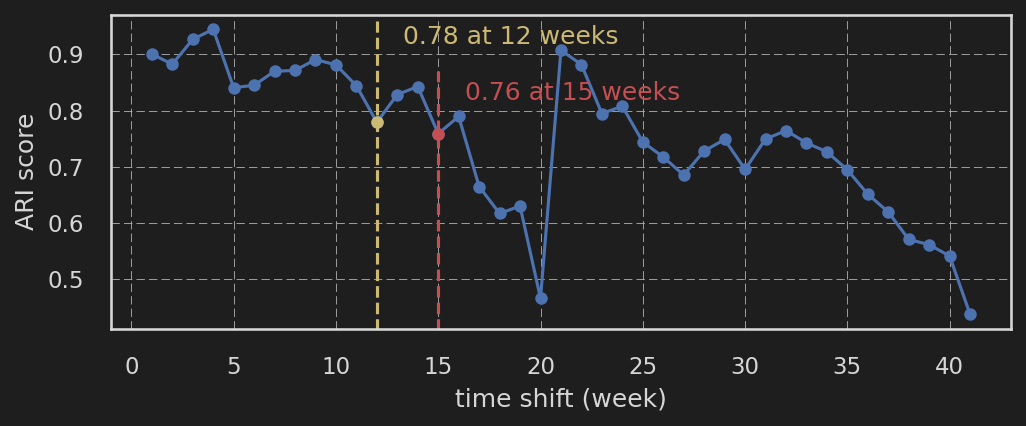

In [31]:
k = 4
compute_ARI_full( df_merged, t0, timespan, timeshift, k )

## Remarques
* Prendre 4 clusters au lieu de 5 fusionne un petit cluster (correspondant aux montants les plus élevés) avec un plus gros proche (montants élevés).
* le score ARI descend en dessous de 0.8 pour 7 / 12 semaines pour 5 clusters, et 12 / 15 semaines pour 4 clusters.